# **Experiment A-01 - ConstLW Output Forms**

---

## **🔴 Context**

- First experiment testing if `ConstLW` can be trained as a LW parameterization scheme.

---

## **🟡 Experiment Questions**


#### **Q1 - Do the chosen training parameters leave room for improvement?**

No directly visible improvements. But it is possible that different training parameters yield better results.

#### **Q2 - How does ConstLW schemes perform? Are they stable?**

`ConstLW` generally outperforms the "no LW" baseline. Stable and a solid baseline / proof of concept. 


#### **Q3 - How does the output form affect performance and stability?**

- Skill: `PlanckOutput` clearly outperforms `LinearOutput` and `DirectOutput` in the RMSE metric for 30 days horizon: `LinearOutput` gets unstable after approx. 20 days and `DirectOutput` yields only big RMSE errors. Regarding bias, `DirectOutput` yields best results.

- Stability: Again, `DirectOutput` yields better RMSE results, but `DirectOutput` performs better in bias.


#### **Q4 - Do the schemes learn independent of seeds?**

The key characteristics are very similar between different seeds. The correlation matrix confirms this.




#### **Q5 - How fast are ConstLW schemes in comparison to OBLW?**

ConstLW schemes are approx. 2-4x faster than OBLW.

---

## **🟢 Short Result**
#### `ConstLW` is not perfect but a good first baseline and better than `ZeroLW`. `PlanckOutput` performs best in RMSE.


---

## **0. Setup**

In [61]:
# Loading packages
using Revise
using NeuralParam
using CairoMakie
using Statistics
using Random

In [2]:
# Define experiment
EXP = "exp_A_01_CLW_outputForms";

## **1. Training**

In [31]:
# Define notebook picture scaling
NB_TRAIN = (; size = (900, 900));

In [33]:
# Define schemes, labels, colors and plotting steps
SCHEMES = ["CLW_direct_s1000", "CLW_direct_s2000", "CLW_linear_s1000", "CLW_linear_s2000", "CLW_planck_s1000", "CLW_planck_s2000"]
LABELS = ["Direct S1", "Direct S2", "Linear S1", "Linear S2", "Planck S1", "Planck S2"]
COLORS = [JL_BLUE, JL_BLUE, JL_GREEN, JL_GREEN, JL_RED, JL_RED];

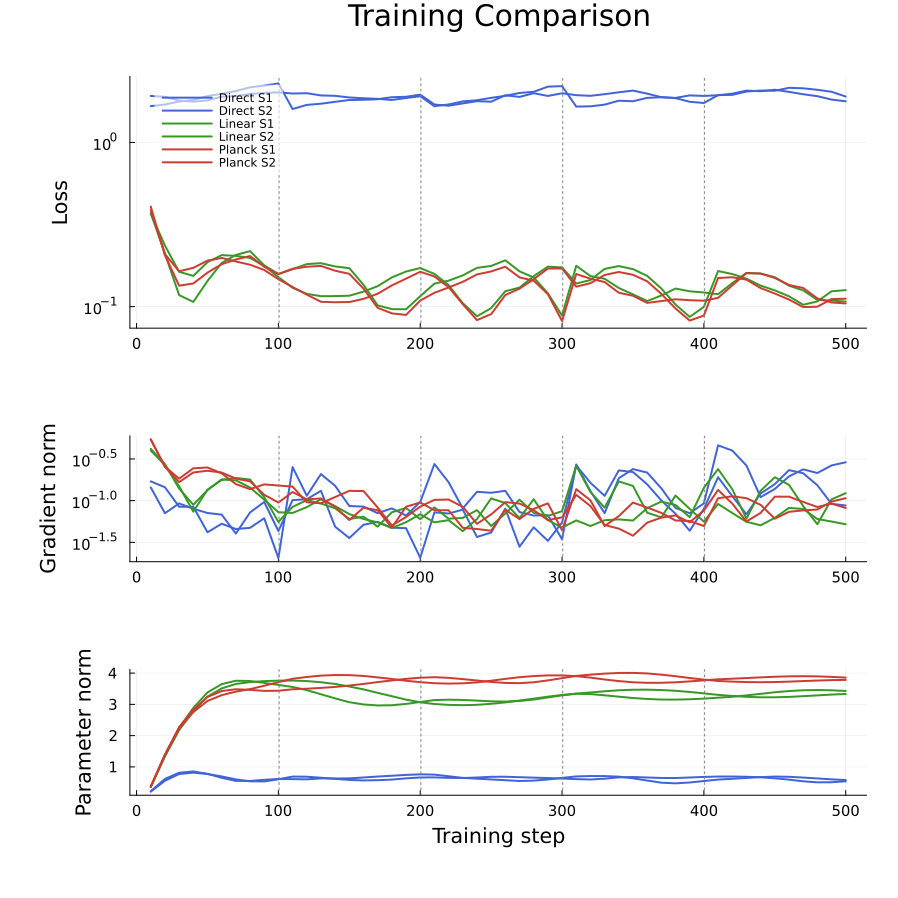

In [34]:
# Plot training comparison
plot_training_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, plot_kwargs = NB_TRAIN)

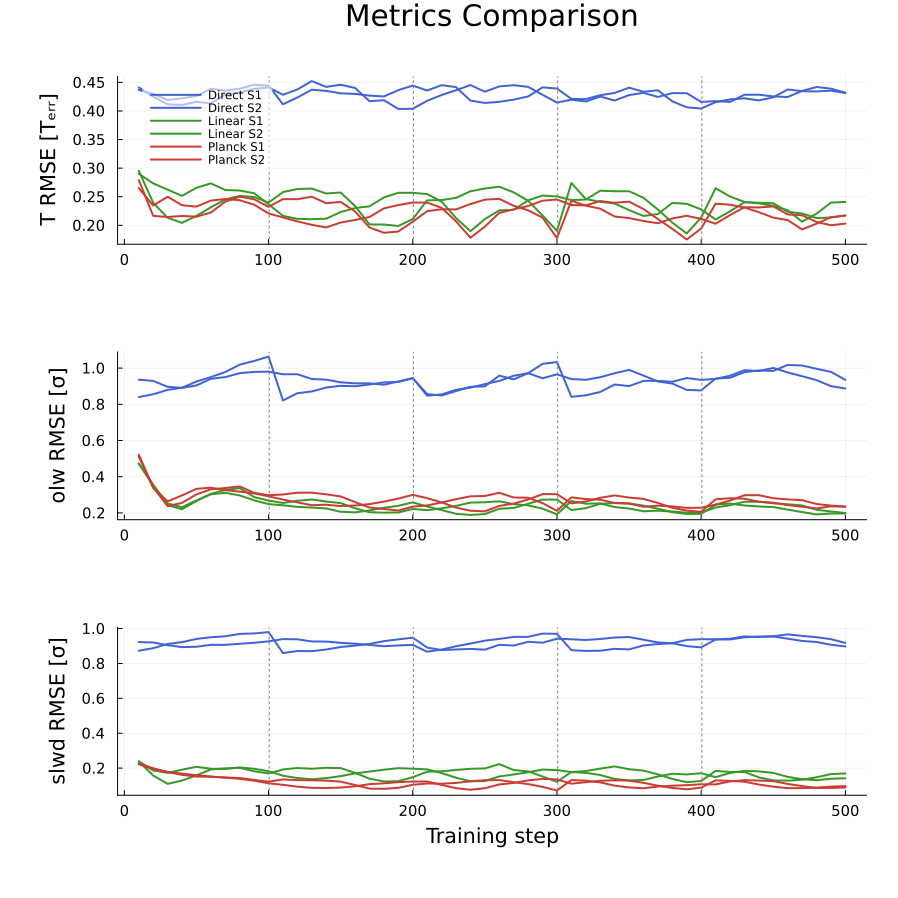

In [35]:
# Training metrics comparison
plot_metrics_comp(; exp = EXP, names = SCHEMES, labels = LABELS, plot_kwargs = NB_TRAIN)

## **2. Rollouts**

In [36]:
# Define notebook picture scaling
NB_ROLLOUT = (; size = (1200, 400));

### 2.1 ZeroLW baseline

In [37]:
# Define rollouts
SKILL_NAMES = [
    "ZeroLW_skill",
    "OBLW_skill",
    "CLW_direct_s1000_skill", 
    "CLW_linear_s1000_skill", 
    "CLW_planck_s1000_skill", 
]

skill = collect_rollouts(EXP, SKILL_NAMES);

# Define labels and colors
LABELS = ["ZeroLW", "OBLW", "CLW direct", "CLW linear", "CLW planck"]
COLORS = [:black, :grey, JL_BLUE, JL_GREEN, JL_RED];

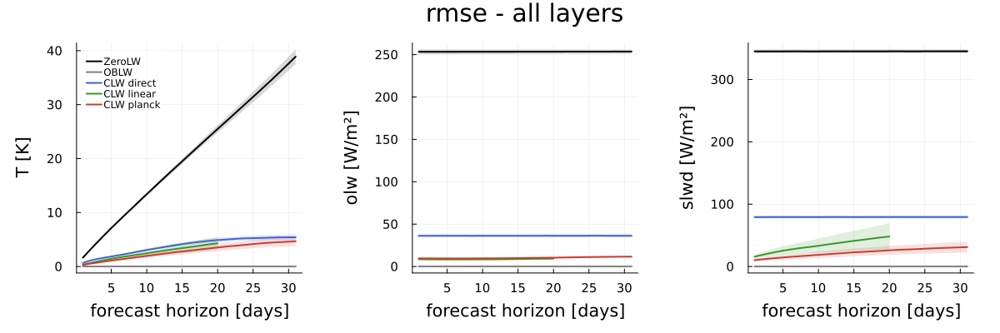

In [38]:
# Plot rmse comparison
plot_rollout(rollouts = skill, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

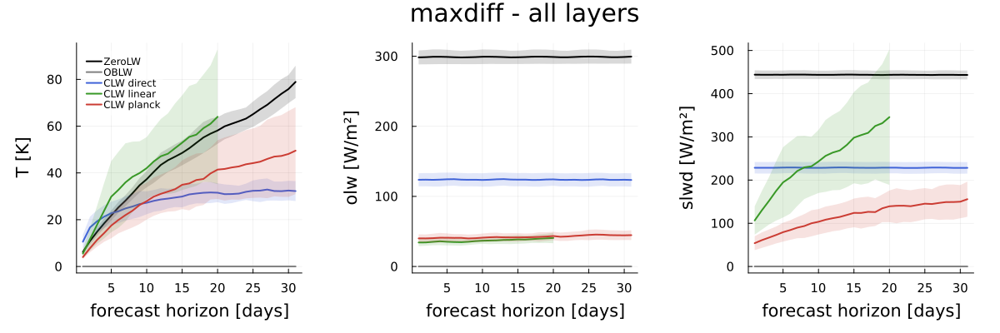

In [39]:
# Plot rmse comparison
plot_rollout(rollouts = skill, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

### 2.2 Skill (31 days)

In [40]:
# Define rollouts
SKILL_NAMES = [
    "OBLW_skill",
    "CLW_direct_s1000_skill",
    "CLW_direct_s2000_skill", 
    "CLW_linear_s1000_skill", 
    "CLW_linear_s2000_skill", 
    "CLW_planck_s1000_skill", 
    "CLW_planck_s2000_skill", 
]
STAB_NAMES = replace.(SKILL_NAMES, "skill" => "stab")


skill = collect_rollouts(EXP, SKILL_NAMES)
stab = collect_rollouts(EXP, STAB_NAMES);

In [41]:
# Define labels and colors
LABELS = ["OBLW", "CLW direct S1", "CLW direct S2", "CLW linear S1", "CLW linear S2", "CLW planck S1", "CLW planck S2"]
COLORS = [:grey, JL_BLUE, JL_BLUE, JL_GREEN, JL_GREEN, JL_RED, JL_RED];

#### 2.2.1 Time Series

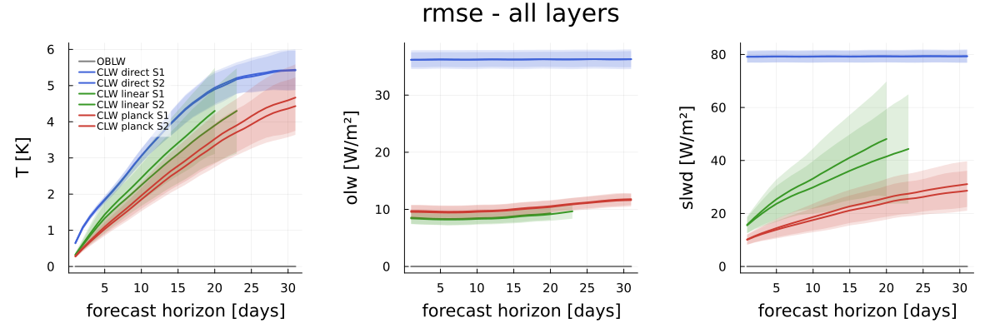

In [43]:
# Plot rmse comparison
plot_rollout(rollouts = skill, metric = :rmse, labels = LABELS, plot_kwargs = NB_ROLLOUT)

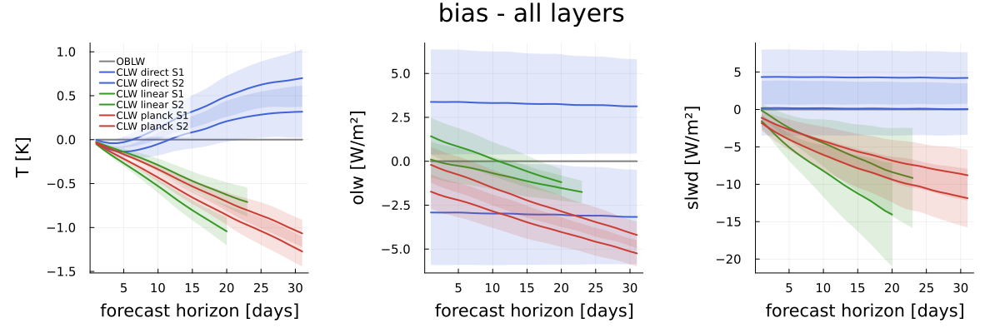

In [44]:
# Plot bias comparison
plot_rollout(rollouts = skill, metric = :bias, labels = LABELS, plot_kwargs = NB_ROLLOUT)

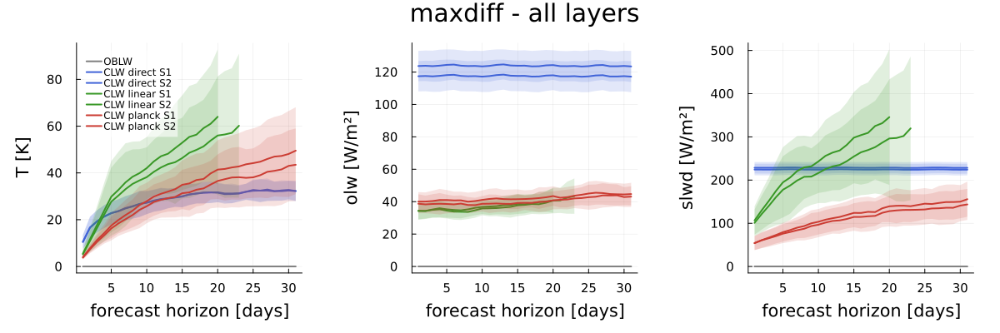

In [45]:
# Plot maxdiff comparison
plot_rollout(rollouts = skill, metric = :maxdiff, labels = LABELS, plot_kwargs = NB_ROLLOUT)

#### 2.2.2 Heatmaps after 14 days

In [46]:
# Define notebook picture scaling
NB_HM = (; width = 400, height = 200, titlesize = 16, suptitlesize = 20);

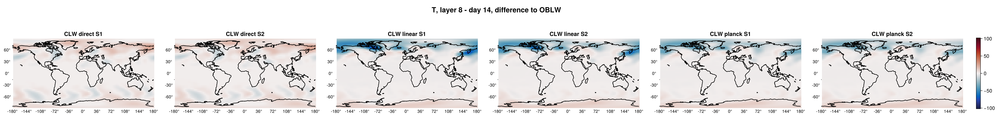

In [48]:
# Heatmap temperature surface layer
plot_rollout_heatmaps(; rollouts = skill, var = :T, ref = :OBLW_skill, layer = 8, labels = LABELS, layout = :horizontal, NB_HM...)[4]

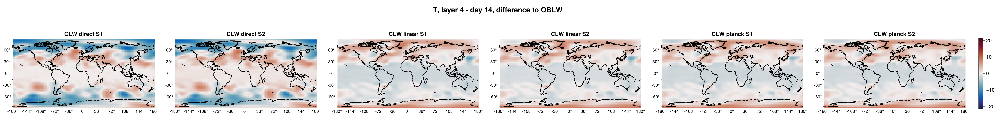

In [50]:
# Heatmap temperature mid layer
plot_rollout_heatmaps(; rollouts = skill, var = :T, ref = :OBLW_skill, layer = 4, labels = LABELS, layout = :horizontal, NB_HM...)[4]

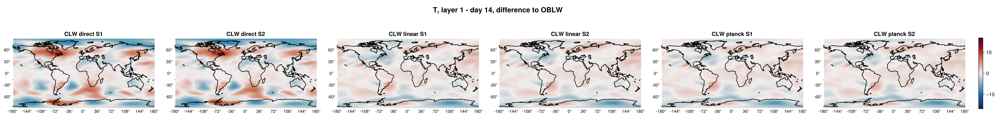

In [51]:
# Heatmap temperature upper layer
plot_rollout_heatmaps(; rollouts = skill, var = :T, ref = :OBLW_skill, layer = 1, labels = LABELS, layout = :horizontal, NB_HM...)[4]

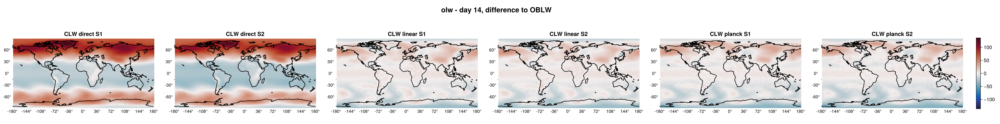

In [52]:
# Heatmap outgoing LW radiation
plot_rollout_heatmaps(; rollouts = skill, var = :olw, ref = :OBLW_skill, labels = LABELS, layout = :horizontal, NB_HM...)[4]

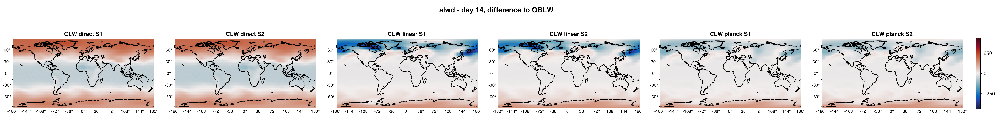

In [53]:
# Heatmap outgoing LW radiation
plot_rollout_heatmaps(; rollouts = skill, var = :slwd, ref = :OBLW_skill, labels = LABELS, layout = :horizontal, NB_HM...)[4]

#### 2.2.3 Correlation

In [54]:
# Variable correlation after 1 day
print_correlation(; rollouts = skill, day = 1, var = (:T, :olw, :slwd), labels = LABELS)

available days: [1, 3, 7, 14, 31]

T, layer mean - day 1                                                                                                olw, layer mean - day 1                                                                                              slwd, layer mean - day 1
                 CLW direct S1  CLW direct S2  CLW linear S1  CLW linear S2  CLW planck S1  CLW planck S2                             CLW direct S1  CLW direct S2  CLW linear S1  CLW linear S2  CLW planck S1  CLW planck S2                             CLW direct S1  CLW direct S2  CLW linear S1  CLW linear S2  CLW planck S1  CLW planck S2
CLW direct S1              1.0          0.999           0.31          0.368           0.29          0.329            CLW direct S1              1.0            1.0          0.273           0.19          0.289          0.204            CLW direct S1              1.0            1.0         -0.062          0.011         -0.069         -0.032
CLW direct S2            0

In [55]:
# Variable correlation after 7 days
print_correlation(; rollouts = skill, day = 7, var = (:T, :olw, :slwd), labels = LABELS)

available days: [1, 3, 7, 14, 31]

T, layer mean - day 7                                                                                                olw, layer mean - day 7                                                                                              slwd, layer mean - day 7
                 CLW direct S1  CLW direct S2  CLW linear S1  CLW linear S2  CLW planck S1  CLW planck S2                             CLW direct S1  CLW direct S2  CLW linear S1  CLW linear S2  CLW planck S1  CLW planck S2                             CLW direct S1  CLW direct S2  CLW linear S1  CLW linear S2  CLW planck S1  CLW planck S2
CLW direct S1              1.0          0.998           0.15          0.233          0.158          0.201            CLW direct S1              1.0            1.0          0.302          0.206          0.384          0.293            CLW direct S1              1.0            1.0         -0.302         -0.234         -0.186         -0.125
CLW direct S2            0

In [57]:
# Variable correlation after 31 days
print_correlation(; rollouts = skill, day = 31, var = (:T, :olw, :slwd), labels = LABELS)

available days: [1, 3, 7, 14, 31]

T, layer mean - day 31                                                                 olw, layer mean - day 31                                                               slwd, layer mean - day 31
                 CLW direct S1  CLW direct S2  CLW planck S1  CLW planck S2                             CLW direct S1  CLW direct S2  CLW planck S1  CLW planck S2                             CLW direct S1  CLW direct S2  CLW planck S1  CLW planck S2
CLW direct S1              1.0          0.775          0.255          0.253            CLW direct S1              1.0            1.0          0.589          0.496            CLW direct S1              1.0            1.0         -0.167         -0.123
CLW direct S2            0.775            1.0          0.197           0.21            CLW direct S2              1.0            1.0          0.589          0.496            CLW direct S2              1.0            1.0         -0.167         -0.123
CLW planck S1  

### 2.3 Stability (365 days)

#### 2.3.1 Time Series

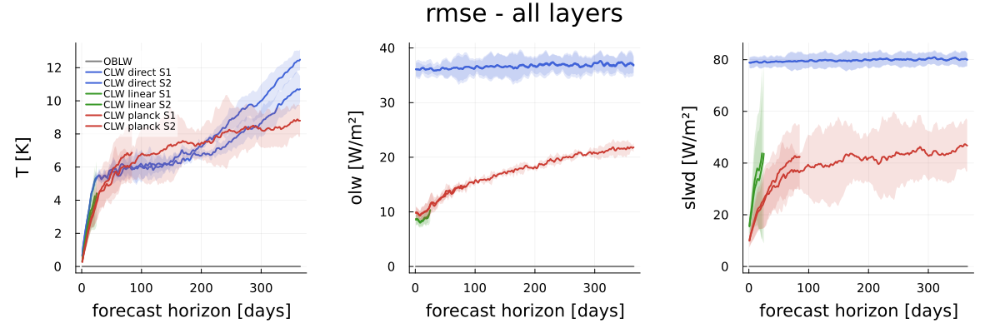

In [58]:
# Plot rmse comparison
plot_rollout(rollouts = stab, metric = :rmse, labels = LABELS, plot_kwargs = NB_ROLLOUT)

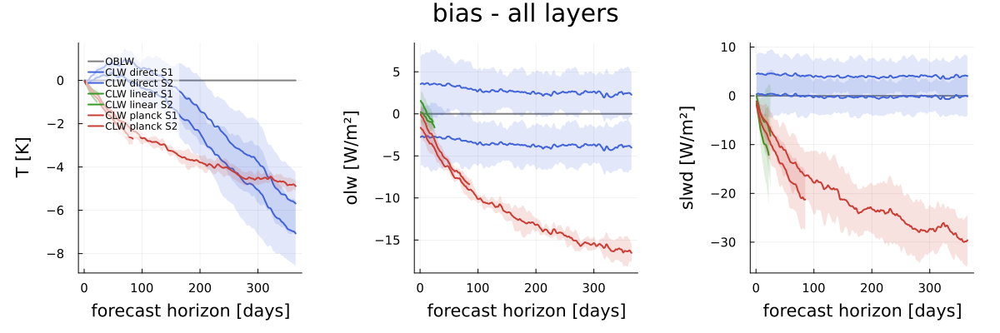

In [59]:
# Plot bias comparison
plot_rollout(rollouts = stab, metric = :bias, labels = LABELS, plot_kwargs = NB_ROLLOUT)

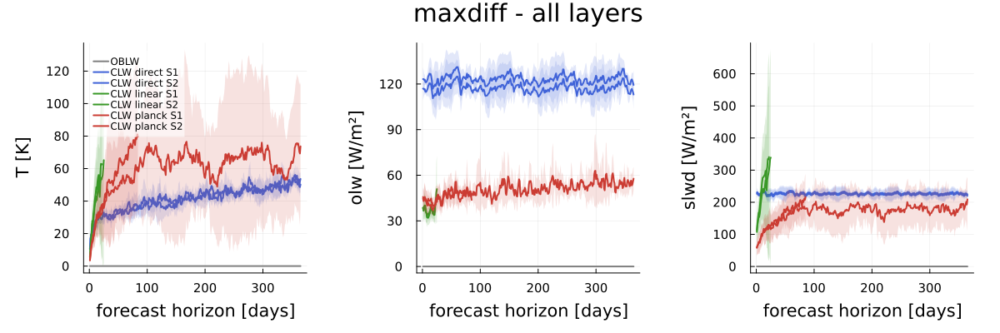

In [60]:
# Plot maxdiff comparison
plot_rollout(rollouts = stab, metric = :maxdiff, labels = LABELS, plot_kwargs = NB_ROLLOUT)

## **3. Benchmark**

In [28]:
# Define spectral grid for benchmark evaluation
using SpeedyWeather
SG = SpectralGrid(trunc = 31, nlayers = 8);

In [29]:
# Load schemes
schemes = merge(
    (; OBLW = build_scheme(:OBLW, SG), 
    ZeroLW = build_scheme(:ZeroLW, SG)),
    collect_schemes(EXP, ["CLW_direct_s1000", "CLW_direct_s2000", "CLW_linear_s1000", "CLW_linear_s2000", "CLW_planck_s1000", "CLW_planck_s2000"]),
);

In [63]:
# Evaluate and print bencnhmark results
res = benchmark_scheme(schemes; spectral_grid = SG)
print_benchmark(res; baseline = :OBLW);


scheme                    ms/step   med/min     KB/step      allocs    rel.
---------------------------------------------------------------------------
OBLW                       0.6646      1.03         0.0           0    1.0×
ZeroLW                      0.006      1.02         0.0           0   0.01×
CLW_direct_s1000           0.1625      1.04       297.0        3168   0.24×
CLW_direct_s2000            0.163      1.15       297.0        3168   0.25×
CLW_linear_s1000           0.2076      1.12       445.5        3168   0.31×
CLW_linear_s2000           0.2113       1.1       445.5        3168   0.32×
CLW_planck_s1000           0.3234      1.02       445.5        3168   0.49×
CLW_planck_s2000            0.323      1.02       445.5        3168   0.49×


┌ Warning: Machine was not quiet (med/min up to 1.15) — rerun before trusting differences.
└ @ NeuralParam c:\Code\NeuralParam.jl\src\evaluation\evaluate_benchmark.jl:133
